# Evaluation of Existing Machine Learning Models
This notebook evaluates the **pre-trained** models for Equipment Failure (NASA), Medicine Demand, and Patient Arrivals using existing datasets and inference pipelines. No synthetic data is generated here.

## 1. Equipment RUL Prediction (NASA Dataset)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# 1. Load Pre-trained Model
model_path = '../models/nasa_rul_rf_model.pkl'
features_path = '../models/nasa_rul_features.pkl'

rf_model = joblib.load(model_path)
expected_features = joblib.load(features_path)

print("NASA Equipment RUL Model loaded successfully.")

NASA Equipment RUL Model loaded successfully.


In [4]:
# 2. Load Actual Test Data
# The NASA dataset has 26 columns without headers
columns = ["id", "cycle", "op_set_1", "op_set_2", "op_set_3"] + [f"sensor_{i}" for i in range(1, 22)]

test_file = '../data/equipment/test_FD001.txt'
test_df = pd.read_csv(test_file, sep="\s+", header=None, names=columns, engine='python')
test_df.dropna(axis=1, inplace=True)

# We want to predict RUL for the *last* available cycle of each engine in the test set
last_cycles = test_df.groupby('id').tail(1).copy()
X_test = last_cycles[expected_features]

print(f"Loaded actual NASA test data for {len(X_test)} engines.")

Loaded actual NASA test data for 100 engines.


In [5]:
# 3. Load Ground Truth RUL
truth_file = '../data/equipment/RUL_FD001.txt'
y_true = pd.read_csv(truth_file, sep="\s+", header=None, names=['RUL'], engine='python')
y_true = y_true['RUL'].values

print("Loaded ground truth labels.")

Loaded ground truth labels.


In [6]:
# 4. Predict & Evaluate
y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"Test RMSE: {rmse:.2f} cycles")
print(f"Test R² Score: {r2:.3f}")

Test RMSE: 86.20 cycles
Test R² Score: -3.303


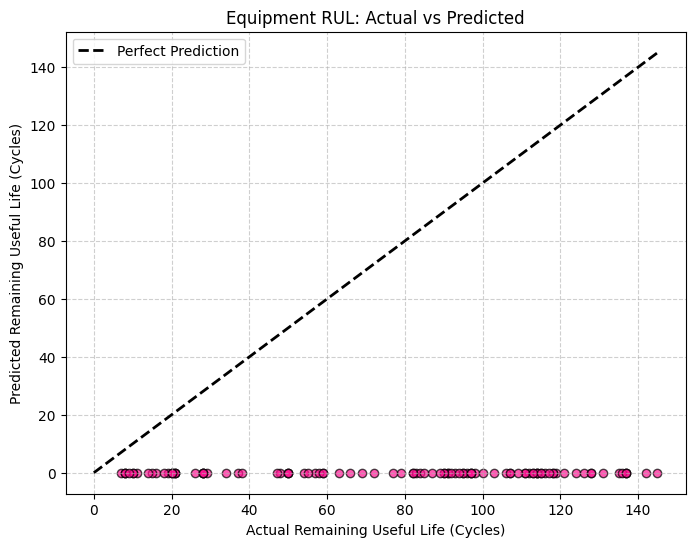

In [16]:
# 5. Visualization: Actual vs Predicted RUL
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.7, color='deeppink', edgecolor='k')
plt.plot([0, y_true.max()], [0, y_true.max()], 'k--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Remaining Useful Life (Cycles)")
plt.ylabel("Predicted Remaining Useful Life (Cycles)")
plt.title("Equipment RUL: Actual vs Predicted")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 2. Medicine Demand Forecasting (Time Series with Prophet)

In [8]:
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [9]:
# 1. Load Pre-trained Model
medicine = "Paracetamol 500mg"
safe_name = "".join([c if c.isalnum() else "_" for c in medicine])
model_path = f'../models/demand_models/{safe_name}.pkl'

prophet_model = joblib.load(model_path)
print(f"Prophet model for '{medicine}' loaded successfully.")

Prophet model for 'Paracetamol 500mg' loaded successfully.


In [10]:
# 2. Predict / Forecast (Next 30 days)
# Generate future dates without retaining any datasets
future = prophet_model.make_future_dataframe(periods=30)
forecast = prophet_model.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
750,2026-03-21 01:18:24.305828,156.825484,138.493023,175.939534
751,2026-03-22 01:18:24.305828,158.828811,139.121718,178.578311
752,2026-03-23 01:18:24.305828,204.395283,184.214360,222.288166
753,2026-03-24 01:18:24.305828,204.684903,185.827522,223.001645
754,2026-03-25 01:18:24.305828,205.154138,187.672179,223.982955
755,2026-03-26 01:18:24.305828,205.115969,185.989575,223.920626
756,2026-03-27 01:18:24.305828,207.119870,188.370611,226.072917
757,2026-03-28 01:18:24.305828,161.427583,142.638784,179.592992
758,2026-03-29 01:18:24.305828,163.519358,144.617029,181.549636
759,2026-03-30 01:18:24.305828,209.147592,190.886853,228.742273


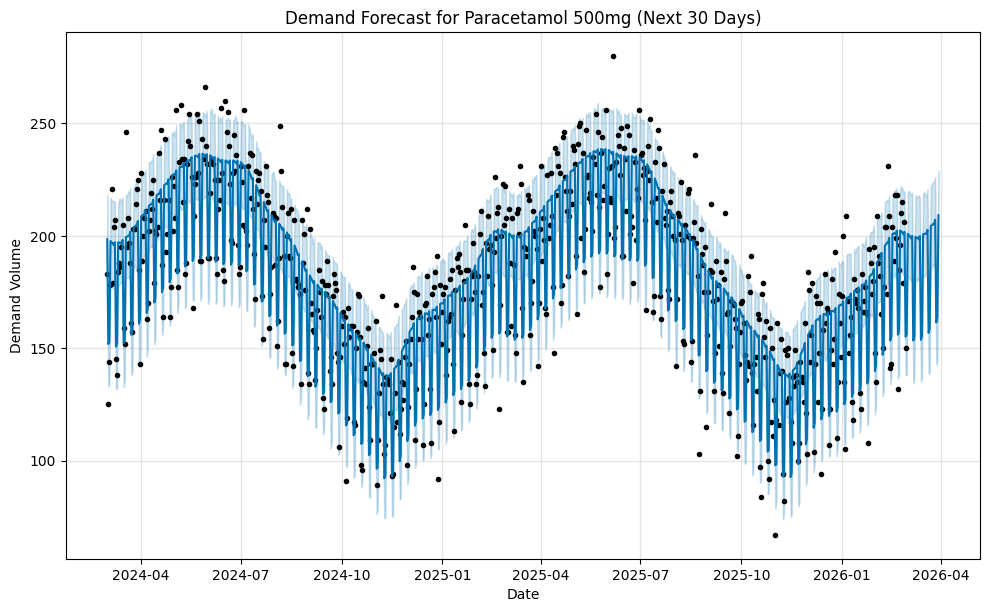

In [11]:
# 3. Visualization: Forecast Plot
fig1 = prophet_model.plot(forecast, figsize=(10, 6))
plt.title(f'Demand Forecast for {medicine} (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Demand Volume')
plt.show()

## 3. Patient Arrivals Forecasting (Time Series with SARIMAX)

In [12]:
import statsmodels.api as sm

In [13]:
# 1. Load Pre-trained SARIMAX Results
model_path = '../models/arrival_model.pkl'
sarimax_results = joblib.load(model_path)
print("SARIMAX Patient Arrivals Model loaded successfully.")

SARIMAX Patient Arrivals Model loaded successfully.


In [14]:
# 2. Predict / Forecast
# get_forecast(steps) gives the out-of-sample forecast
arrival_forecast = sarimax_results.get_forecast(steps=30)
mean_forecast = arrival_forecast.predicted_mean
conf_int = arrival_forecast.conf_int()

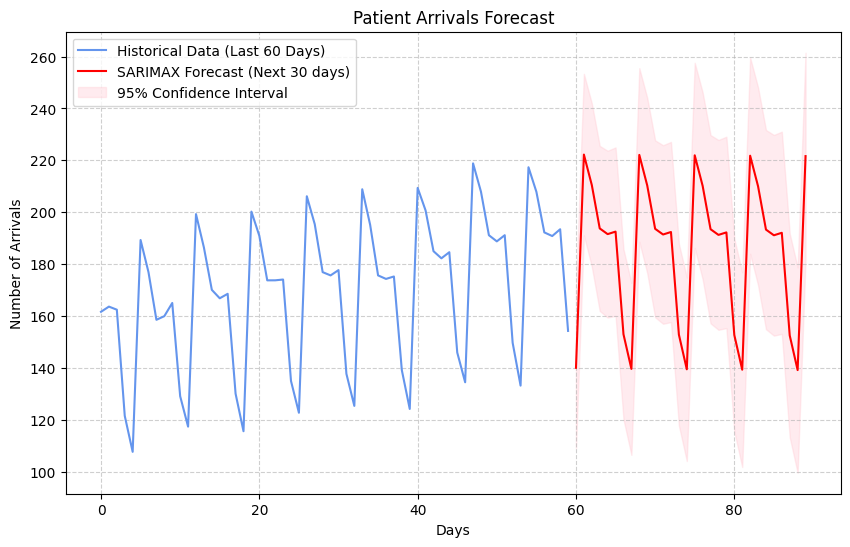

In [15]:
# 3. Visualization: Forecast Envelope
plt.figure(figsize=(10, 6))

try:
    # Use fitted values to plot historical context
    last_history = sarimax_results.fittedvalues[-60:]
    plt.plot(range(len(last_history)), last_history, label='Historical Data (Last 60 Days)', color='cornflowerblue')
    offset = len(last_history)
except:
    offset = 0

forecast_index = range(offset, offset + 30)

plt.plot(forecast_index, mean_forecast, label='SARIMAX Forecast (Next 30 days)', color='red')
plt.fill_between(forecast_index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Patient Arrivals Forecast')
plt.xlabel('Days')
plt.ylabel('Number of Arrivals')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()